# Lectura y descripción del dataset `cs_construccion`

En este notebook cargamos el fichero **`cs_construccion.csv`** y utilizamos **`DataDictionary.csv`** para conocer el significado de cada columna.

El conjunto de datos corresponde al problema de *credit scoring* **"Give Me Some Credit"**: cada fila es un solicitante de crédito y el objetivo es predecir si sufrirá una morosidad grave en los próximos 2 años (`SeriousDlqin2yrs`).

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Lectura del dataset principal (separador por comas, con cabecera)
df = pd.read_csv("cs_construccion.csv")

print(f"Dimensiones del dataset: {df.shape[0]} filas x {df.shape[1]} columnas")
df.head()

Dimensiones del dataset: 105000 filas x 11 columnas


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,0,0.090577,59,0,0.289273,7466.0,17,0,2,0,1.0
1,0,0.019327,74,0,1.505535,541.0,16,0,1,0,0.0
2,0,0.670039,34,0,0.081489,7816.0,9,0,0,0,0.0
3,0,1.000000,66,0,0.209132,6000.0,4,0,1,0,0.0
4,0,0.138060,65,1,100.000000,NaN,2,0,0,0,NaN


## Significado de cada columna (en español)

Descripción de cada variable de `cs_construccion.csv` según `DataDictionary.csv`, traducida al español:

| # | Columna | Significado | Tipo |
|---|---------|-------------|------|
| 0 | `SeriousDlqin2yrs` | **Variable objetivo:** la persona sufrió una morosidad grave (impago de 90 días o más) en los últimos 2 años. | Binaria (0/1) |
| 1 | `RevolvingUtilizationOfUnsecuredLines` | Saldo total en tarjetas de crédito y líneas de crédito personales (excluyendo inmuebles y préstamos a plazos como el del coche) dividido entre la suma de los límites de crédito. | Porcentaje |
| 2 | `age` | Edad del solicitante en años. | Entero |
| 3 | `NumberOfTime30-59DaysPastDueNotWorse` | Número de veces que el solicitante ha tenido entre 30 y 59 días de retraso en el pago (sin llegar a peor) en los últimos 2 años. | Entero |
| 4 | `DebtRatio` | Pagos mensuales de deuda, pensiones y gastos de manutención divididos entre los ingresos mensuales brutos. | Porcentaje |
| 5 | `MonthlyIncome` | Ingresos mensuales. | Real |
| 6 | `NumberOfOpenCreditLinesAndLoans` | Número de préstamos abiertos (a plazos, como el del coche o la hipoteca) y líneas de crédito (p. ej. tarjetas de crédito). | Entero |
| 7 | `NumberOfTimes90DaysLate` | Número de veces que el solicitante ha tenido 90 días o más de retraso en el pago. | Entero |
| 8 | `NumberRealEstateLoansOrLines` | Número de préstamos hipotecarios e inmobiliarios, incluyendo líneas de crédito con garantía hipotecaria. | Entero |
| 9 | `NumberOfTime60-89DaysPastDueNotWorse` | Número de veces que el solicitante ha tenido entre 60 y 89 días de retraso en el pago (sin llegar a peor) en los últimos 2 años. | Entero |
| 10 | `NumberOfDependents` | Número de personas a cargo en la familia, sin contarse a sí mismo (cónyuge, hijos, etc.). | Entero |

## Rango de valores de cada variable

Antes de modelar, revisamos el rango en el que se mueve cada variable (mínimo, máximo, cuartiles) y los valores ausentes. Esto permite detectar posibles anomalías y decidir qué habrá que limpiar o imputar.

In [19]:
# Estadísticos descriptivos: rango (min/max), cuartiles y media de cada variable
resumen = df.describe().T

# Añadimos el número y el porcentaje de valores ausentes por columna
resumen["nulos"] = df.isna().sum()
resumen["% nulos"] = (df.isna().mean() * 100).round(2)

resumen

,count,mean,std,min,25%,50%,75%,max,nulos,% nulos
SeriousDlqin2yrs,105000.0,0.066838,0.249743,0.0,0.000000,0.000000,0.000000,1.0,0,0.00
RevolvingUtilizationOfUnsecuredLines,105000.0,6.146972,217.681366,0.0,0.029939,0.154674,0.561067,22198.0,0,0.00
age,105000.0,52.221610,14.765680,0.0,41.000000,52.000000,63.000000,109.0,0,0.00
NumberOfTime30-59DaysPastDueNotWorse,105000.0,0.419933,4.188991,0.0,0.000000,0.000000,0.000000,98.0,0,0.00
DebtRatio,105000.0,354.160487,1999.455352,0.0,0.174872,0.366143,0.869178,329664.0,0,0.00
MonthlyIncome,84205.0,6700.439214,15368.210022,0.0,3400.000000,5400.000000,8250.000000,3008750.0,20795,19.80
NumberOfOpenCreditLinesAndLoans,105000.0,8.440276,5.130889,0.0,5.000000,8.000000,11.000000,58.0,0,0.00
NumberOfTimes90DaysLate,105000.0,0.265105,4.166023,0.0,0.000000,0.000000,0.000000,98.0,0,0.00
NumberRealEstateLoansOrLines,105000.0,1.016429,1.133977,0.0,0.000000,1.000000,2.000000,54.0,0,0.00
NumberOfTime60-89DaysPastDueNotWorse,105000.0,0.239286,4.151858,0.0,0.000000,0.000000,0.000000,98.0,0,0.00


In [20]:
# Comprobación del caso anómalo age = 0
n_age_cero = (df["age"] == 0).sum()
print(f"Número de solicitantes con age = 0: {n_age_cero}")

# Mostramos las filas afectadas
df[df["age"] == 0]

Número de solicitantes con age = 0: 1


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
89320,0,1.0,0,1,0.436927,6000.0,6,0,2,0,2.0


### Anomalías detectadas en los rangos

Observando los rangos aparecen varios problemas de calidad de datos que habrá que tratar antes de modelar:

| Variable | Qué se observa | Por qué es sospechoso |
|---|---|---|
| `age` | mínimo = **0** | Imposible para un solicitante de crédito (hay 1 caso). |
| `RevolvingUtilizationOfUnsecuredLines` | máximo ≈ **22.198** | Debería ser un ratio cercano a 0–1; hay valores extremos (*outliers*). |
| `DebtRatio` | máximo ≈ **329.664** | Ratio disparado; *outliers* muy alejados de la mediana. |
| `MonthlyIncome` | máximo ≈ **3.008.750** y **~20.795 nulos (≈20%)** | Valores extremos y una fracción importante de datos ausentes. |
| `NumberOfTime30-59DaysPastDueNotWorse`, `NumberOfTimes90DaysLate`, `NumberOfTime60-89DaysPastDueNotWorse` | máximo = **96 / 98** | Saltan bruscamente desde ~13; son **valores centinela** (códigos de "no disponible"), no cuentas reales. |
| `NumberOfDependents` | **~2.738 nulos** | Valores ausentes que habrá que imputar. |

**Conclusión:** antes de entrenar cualquier modelo será necesario (1) imputar los nulos de `MonthlyIncome` y `NumberOfDependents`, (2) tratar los *outliers* de los ratios y (3) decidir qué hacer con los valores centinela (96/98) de los contadores de morosidad y con la edad = 0.

## Limpieza de datos

### `age`: eliminación del registro con edad 0

Al tratarse de un único registro con un valor imposible (`age = 0`), lo eliminamos. Al ser una sola fila entre 105.000, no hay pérdida de información relevante ni impacto estadístico.

In [21]:
# Eliminamos la fila con age = 0
antes = len(df)
df = df[df["age"] > 0].reset_index(drop=True)
print(f"Filas eliminadas por age = 0: {antes - len(df)}")
print(f"Dimensiones tras la limpieza: {df.shape[0]} filas x {df.shape[1]} columnas")

Filas eliminadas por age = 0: 1
Dimensiones tras la limpieza: 104999 filas x 11 columnas


### Funciones auxiliares de limpieza

Varias operaciones de limpieza se repiten en más de una variable, así que las extraemos en funciones reutilizables para no duplicar código:

- `resumen_por_tramo_edad`: mediana, media y nº de casos de una variable por tramo de edad (sirve para justificar la relación con la edad).
- `imputar_por_tramo_edad`: crea la columna indicadora `{variable}_missing` e imputa los nulos con la mediana de su tramo de edad.
- `outliers_por_umbral`: para una lista de umbrales, resume cuántas filas los superan, qué porcentaje del total representan y su tasa de morosidad (con columnas extra opcionales), para decidir cómo tratar los *outliers*.

In [22]:
# Cortes de edad usados en toda la imputación por tramos
cortes = [0, 30, 40, 50, 60, 70, 150]


def resumen_por_tramo_edad(df, columna, cortes):
    """Mediana, media y nº de casos (no nulos) de `columna` por tramo de edad.

    Útil para comprobar/justificar si existe relación entre la edad y la variable.
    """
    sub = df.dropna(subset=[columna])
    grupo = sub.groupby(pd.cut(sub["age"], cortes), observed=True)[columna]
    return pd.concat(
        [grupo.median().rename("mediana"),
         grupo.mean().round(2).rename("media"),
         grupo.size().rename("n")],
        axis=1,
    )


def imputar_por_tramo_edad(df, columna, cortes, crear_flag=True):
    """Imputa los nulos de `columna` con la mediana de su tramo de edad (in place).

    Si `crear_flag` es True, añade primero la columna indicadora `{columna}_missing`
    (1 si el valor estaba ausente, 0 si no), ya que la propia ausencia puede ser informativa.
    """
    if crear_flag:
        df[f"{columna}_missing"] = df[columna].isna().astype(int)

    mediana_tramo = df.groupby(pd.cut(df["age"], cortes), observed=True)[columna].transform("median")
    n_antes = df[columna].isna().sum()
    df[columna] = df[columna].fillna(mediana_tramo)

    print(f"[{columna}] valores imputados: {n_antes} | nulos restantes: {df[columna].isna().sum()}")
    if crear_flag:
        print(f"[{columna}] individuos con {columna}_missing = 1: {df[f'{columna}_missing'].sum()}")


def outliers_por_umbral(df, columna, umbrales, objetivo="SeriousDlqin2yrs", cols_extra=None):
    """Resumen de outliers de `columna` para una lista de umbrales.

    Para cada umbral devuelve el nº de filas con valor > umbral, su % sobre el total y la
    tasa media de `objetivo` (morosidad) en ese grupo. `cols_extra` permite añadir el
    porcentaje medio de columnas binarias adicionales (p. ej. un flag de valor ausente).
    """
    cols_extra = cols_extra or []
    filas = []
    for umbral in umbrales:
        grupo = df[df[columna] > umbral]
        fila = {
            "umbral (>)": umbral,
            "n_filas": len(grupo),
            "% del total": round(len(grupo) / len(df) * 100, 2),
            "morosidad %": round(grupo[objetivo].mean() * 100, 2),
        }
        for c in cols_extra:
            fila[f"% {c}"] = round(grupo[c].mean() * 100, 1)
        filas.append(fila)
    return pd.DataFrame(filas).set_index("umbral (>)")

### `MonthlyIncome`: imputación por mediana según tramo de edad

`MonthlyIncome` tiene ~20% de valores ausentes, por lo que eliminar esas filas no es viable (perderíamos una quinta parte del dataset e introduciríamos sesgo). En su lugar, imputamos, pero antes justificamos **con qué** imputar.

En vez de una mediana global, buscamos una variable que se relacione con el ingreso para hacer una imputación condicional. La siguiente celda analiza dos cosas: la correlación lineal de `MonthlyIncome` con el resto de variables y su mediana por tramo de edad.

In [23]:
# --- Justificación de la variable de agrupación ---

# 1) Correlación lineal de MonthlyIncome con el resto (solo filas con ingreso conocido)
conocidos = df.dropna(subset=["MonthlyIncome"])
corr = (conocidos.corr(numeric_only=True)["MonthlyIncome"]
        .drop("MonthlyIncome")
        .sort_values(key=abs, ascending=False))
print("Correlación lineal de MonthlyIncome con el resto de variables:")
print(corr.round(3))

# 2) Mediana/media de MonthlyIncome por tramo de edad (usa la función auxiliar)
print("\nMonthlyIncome por tramo de edad:")
print(resumen_por_tramo_edad(df, "MonthlyIncome", cortes))
print(f"\nMediana global de MonthlyIncome: {df['MonthlyIncome'].median()}")

Correlación lineal de MonthlyIncome con el resto de variables:
NumberRealEstateLoansOrLines            0.119
NumberOfOpenCreditLinesAndLoans         0.085
NumberOfDependents                      0.063
age                                     0.033
DebtRatio                              -0.027
SeriousDlqin2yrs                       -0.018
NumberOfTimes90DaysLate                -0.012
NumberOfTime60-89DaysPastDueNotWorse   -0.010
NumberOfTime30-59DaysPastDueNotWorse   -0.009
RevolvingUtilizationOfUnsecuredLines    0.004
Name: MonthlyIncome, dtype: float64

MonthlyIncome por tramo de edad:
           mediana    media      n
age                               
(0, 30]     2800.0  3213.71   6373
(30, 40]    4950.0  5770.31  14893
(40, 50]    6083.0  7446.38  20650
(50, 60]    6307.0  7856.50  19459
(60, 70]    5833.0  7280.22  14375
(70, 150]   4500.0  5498.67   8454

Mediana global de MonthlyIncome: 5400.0


**Interpretación:** las correlaciones lineales son todas muy débiles (la mayor, ≈0,12, con `NumberRealEstateLoansOrLines`; `age` apenas 0,03). Sin embargo, la mediana por tramo de edad revela una relación clara en **U invertida**: el ingreso sube desde ~2.800 (menores de 30) hasta un pico de ~6.300 (50–60 años) y luego baja en la jubilación (~4.500). Esta relación no lineal la pierde la correlación de Pearson, pero es real y relevante (rango de 2.800 a 6.300 frente a la mediana global de 5.400).

Por tanto, **imputamos `MonthlyIncome` con la mediana de su tramo de edad**. Además, creamos la columna indicadora `MonthlyIncome_missing`: el hecho de no declarar ingresos puede ser informativo para predecir la morosidad, y conservar esa señal es prácticamente gratis.

In [24]:
# Imputación de MonthlyIncome por mediana de tramo de edad + columna indicadora MonthlyIncome_missing
imputar_por_tramo_edad(df, "MonthlyIncome", cortes)

[MonthlyIncome] valores imputados: 20795 | nulos restantes: 0
[MonthlyIncome] individuos con MonthlyIncome_missing = 1: 20795


### `NumberOfDependents`: imputación por mediana según tramo de edad

`NumberOfDependents` tiene ~2,6% de nulos. Aplicamos el mismo enfoque que en `MonthlyIncome`, bajo la hipótesis de que la edad también se relaciona con el número de personas a cargo. La siguiente celda lo comprueba con la función `resumen_por_tramo_edad`.

In [25]:
# Relación entre edad y número de dependientes (reutiliza la función auxiliar)
print("NumberOfDependents por tramo de edad:")
print(resumen_por_tramo_edad(df, "NumberOfDependents", cortes))
print(f"\nMediana global de NumberOfDependents: {df['NumberOfDependents'].median()}")

NumberOfDependents por tramo de edad:
           mediana  media      n
age                             
(0, 30]        0.0   0.33   7261
(30, 40]       1.0   1.01  17010
(40, 50]       1.0   1.28  24227
(50, 60]       0.0   0.78  23753
(60, 70]       0.0   0.34  18656
(70, 150]      0.0   0.16  11354

Mediana global de NumberOfDependents: 0.0


**Interpretación:** la **media** por tramo confirma la relación esperada en forma de U invertida (0,33 en menores de 30 → pico de 1,28 en los 40–50 → 0,16 en mayores de 70): tiene sentido, pocos dependientes de joven, máximo en la mediana edad y "nido vacío" al envejecer. Ahora bien, la variable está muy concentrada en 0 (≈58% de los casos), por lo que la **mediana** solo distingue el tramo 30–50 (mediana 1) del resto (mediana 0); la señal es real pero modesta.

Aun así, imputamos con la **mediana del tramo de edad** por coherencia con `MonthlyIncome` (mejora ligeramente la mediana global, que sería 0 para todos) y, como solo hay un ~2,6% de nulos, la decisión apenas afecta al dataset. También añadimos la columna indicadora `NumberOfDependents_missing`.

In [26]:
# Imputación de NumberOfDependents por mediana de tramo de edad + columna indicadora NumberOfDependents_missing
imputar_por_tramo_edad(df, "NumberOfDependents", cortes)

[NumberOfDependents] valores imputados: 2738 | nulos restantes: 0
[NumberOfDependents] individuos con NumberOfDependents_missing = 1: 2738


### `RevolvingUtilizationOfUnsecuredLines`: winsorización de la cola extrema

Esta variable es un ratio de utilización del crédito (saldo / límite), que debería moverse en torno a 0–1, aunque valores algo por encima de 1 son legítimos (personas que superan su límite). El análisis de outliers muestra dos realidades distintas:

- **Valores entre 1 y ~2:** no son errores, sino la señal más predictiva del dataset (morosidad del 25–37% frente al 6,7% global). **Se conservan.**
- **Cola extrema (> 10, hasta 22.198):** valores imposibles para un ratio, y con una morosidad (~6,8%) igual a la tasa base, es decir, sin valor predictivo. Son ~176 filas (0,17%) claramente corruptas.

En lugar de eliminar esas filas (perderíamos también su información en el resto de columnas), las **winsorizamos**: recortamos el valor a un tope de 10, conservando la fila.

In [27]:
# Análisis de outliers: nº de casos y tasa de morosidad por umbral (usa la función auxiliar)
print(f"Tasa de morosidad global: {df['SeriousDlqin2yrs'].mean():.2%}  (n={len(df)})\n")
print(outliers_por_umbral(df, "RevolvingUtilizationOfUnsecuredLines", [1, 1.5, 2, 5, 10, 13]))

Tasa de morosidad global: 6.68%  (n=104999)

            n_filas  % del total  morosidad %
umbral (>)                                   
1.0            2383         2.27        37.05
1.5             433         0.41        25.40
2.0             261         0.25        13.03
5.0             184         0.18         7.61
10.0            176         0.17         6.82
13.0            174         0.17         5.75


In [28]:
# Winsorización: recortamos los valores > 10 al tope de 10 (conservando la fila)
TOPE_REVOLVING = 10
col = "RevolvingUtilizationOfUnsecuredLines"

n_afectados = (df[col] > TOPE_REVOLVING).sum()
df[col] = df[col].clip(upper=TOPE_REVOLVING)

print(f"Valores recortados en {col}: {n_afectados}")
print(f"Nuevo máximo de {col}: {df[col].max()}")

Valores recortados en RevolvingUtilizationOfUnsecuredLines: 176
Nuevo máximo de RevolvingUtilizationOfUnsecuredLines: 10.0


### `DebtRatio`: winsorización de la cola extrema

`DebtRatio` es el ratio deuda/ingreso, que debería moverse en torno a 0–1 (mediana 0,37, Q3 0,87). Sin embargo, a partir del percentil 90 los valores saltan a miles, hasta un máximo de ~329.664, imposible para un ratio. La siguiente celda analiza los outliers reutilizando `outliers_por_umbral`, añadiendo como columna extra el flag `MonthlyIncome_missing` para ver su relación con la ausencia de ingreso.

In [29]:
# Análisis de outliers de DebtRatio, incluyendo su relación con el ingreso ausente
print(f"Tasa de morosidad global: {df['SeriousDlqin2yrs'].mean():.2%}  (n={len(df)})\n")
print(outliers_por_umbral(df, "DebtRatio", [1, 2, 5, 100, 1000], cols_extra=["MonthlyIncome_missing"]))

Tasa de morosidad global: 6.68%  (n=104999)

            n_filas  % del total  morosidad %  % MonthlyIncome_missing
umbral (>)                                                            
1             24594        23.42         6.48                     79.4
2             21712        20.68         5.55                     89.5
5             20708        19.72         5.47                     92.1
100           17054        16.24         5.66                     93.1
1000          11884        11.32         4.84                     94.2


**Interpretación:** a diferencia de `RevolvingUtilizationOfUnsecuredLines`, aquí la cola extrema **no es una fracción diminuta** (los valores `> 100` son ~16% del dataset) y **no concentra morosidad** (tasa ≈ o por debajo de la global). Su origen es estructural: como `DebtRatio = deuda / ingreso`, cuando el ingreso es 0 o ausente el ratio explota. Lo confirma el flag: entre los valores `> 2`, el ~90% corresponde a individuos con ingreso ausente (`MonthlyIncome_missing = 1`), información que ya conservamos.

**Winsorizamos** `DebtRatio` al **percentil 95** (≈2.465), recortando solo el ~5% superior y conservando la fila. Es una decisión conservadora: elimina las magnitudes más extremas (hasta ~329.664) con un impacto pequeño en el dataset. Como contrapartida honesta, deja valores todavía implausibles para un ratio (cientos/miles); si se quisiera un criterio más estricto se podría bajar el tope, pero la señal de "sin ingreso" que explica estos casos ya está preservada en `MonthlyIncome_missing`.

In [30]:
# Winsorización: recortamos DebtRatio al percentil 95 (conservando la fila)
col = "DebtRatio"
tope_debtratio = df[col].quantile(0.95)

n_afectados = (df[col] > tope_debtratio).sum()
df[col] = df[col].clip(upper=tope_debtratio)

print(f"Tope (percentil 95) de {col}: {tope_debtratio:.2f}")
print(f"Valores recortados en {col}: {n_afectados} ({n_afectados / len(df):.2%})")
print(f"Nuevo máximo de {col}: {df[col].max()}")

Tope (percentil 95) de DebtRatio: 2465.00
Valores recortados en DebtRatio: 5248 (5.00%)
Nuevo máximo de DebtRatio: 2465.0


### Contadores de morosidad: valores centinela 96/98

Los tres contadores de retrasos en el pago (`NumberOfTime30-59DaysPastDueNotWorse`, `NumberOfTimes90DaysLate`, `NumberOfTime60-89DaysPastDueNotWorse`) contienen los valores **96 y 98**, que no son cuentas reales sino **valores centinela** (códigos reservados para "no disponible"): retrasarse 98 veces en 2 años es imposible, hay un salto brusco desde los valores reales (~8-15) y los códigos aparecen en las mismas filas de las tres columnas a la vez. La siguiente celda lo evidencia.

In [31]:
# --- Evidencia de los valores centinela ---
CENTINELAS = [96, 98]
cols_morosidad = [
    "NumberOfTime30-59DaysPastDueNotWorse",
    "NumberOfTimes90DaysLate",
    "NumberOfTime60-89DaysPastDueNotWorse",
]

# Valores presentes en cada contador (se ve el salto: ...->96, 98)
print("Valores presentes en cada contador:")
for c in cols_morosidad:
    print(f"  {c}: {sorted(int(v) for v in df[c].unique())}")

# Filas afectadas y su morosidad frente a la global
centinela_mask = df[cols_morosidad].isin(CENTINELAS).any(axis=1)
print(f"\nFilas con valor centinela (96/98): {centinela_mask.sum()}")
print(f"Morosidad en esas filas: {df.loc[centinela_mask, 'SeriousDlqin2yrs'].mean():.2%}"
      f"  (global: {df['SeriousDlqin2yrs'].mean():.2%})")

Valores presentes en cada contador:
  NumberOfTime30-59DaysPastDueNotWorse: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 96, 98]
  NumberOfTimes90DaysLate: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 13, 14, 15, 96, 98]
  NumberOfTime60-89DaysPastDueNotWorse: [0, 1, 2, 3, 4, 5, 6, 7, 8, 96, 98]

Filas con valor centinela (96/98): 188
Morosidad en esas filas: 54.26%  (global: 6.68%)


**Decisión:** las 188 filas con centinela tienen una morosidad del **54,26%**, ocho veces la global (6,68%), así que la propia presencia del código es muy informativa. Por eso aplicamos lo siguiente:

1. **Flag compartido** `PastDue_centinela` (las 188 filas coinciden en las tres columnas): conserva la señal de "este registro tenía valores no disponibles", que resultó estar asociada a alta morosidad.
2. **Sustituir cada 96/98 por el máximo legítimo observado en su propia columna** (12, 15 y 8 respectivamente). La justificación es precisamente esa alta morosidad: estos casos se comportan como los deudores más problemáticos, por lo que mapearlos al valor real más alto de la escala es coherente con su riesgo, sin introducir un número imposible (98) que distorsionaría escalas y correlaciones.

In [32]:
# 1) Flag compartido: 1 si la fila tiene un valor centinela en algún contador de morosidad
df["PastDue_centinela"] = df[cols_morosidad].isin(CENTINELAS).any(axis=1).astype(int)

# 2) Sustituir cada centinela por el máximo legítimo de su propia columna
for c in cols_morosidad:
    max_legit = df.loc[~df[c].isin(CENTINELAS), c].max()
    n_cent = df[c].isin(CENTINELAS).sum()
    df.loc[df[c].isin(CENTINELAS), c] = max_legit
    print(f"[{c}] {n_cent} centinelas sustituidos por {max_legit} (máx. legítimo) | nuevo máx.: {df[c].max()}")

print(f"\nFilas marcadas con PastDue_centinela = 1: {df['PastDue_centinela'].sum()}")

[NumberOfTime30-59DaysPastDueNotWorse] 188 centinelas sustituidos por 12 (máx. legítimo) | nuevo máx.: 12
[NumberOfTimes90DaysLate] 188 centinelas sustituidos por 15 (máx. legítimo) | nuevo máx.: 15
[NumberOfTime60-89DaysPastDueNotWorse] 188 centinelas sustituidos por 8 (máx. legítimo) | nuevo máx.: 8

Filas marcadas con PastDue_centinela = 1: 188


## Verificación final del dataset limpio

Comprobamos que, tras toda la limpieza, el `df` está listo para modelar: sin valores ausentes, con los rangos ya saneados y con las nuevas columnas indicadoras añadidas.

In [33]:
# Comprobaciones automáticas del dataset limpio
print(f"Dimensiones finales: {df.shape[0]} filas x {df.shape[1]} columnas")

total_nulos = df.isna().sum().sum()
print(f"Total de valores ausentes: {total_nulos}")
assert total_nulos == 0, "Todavía quedan valores nulos en el dataset"

nuevas_columnas = ["MonthlyIncome_missing", "NumberOfDependents_missing", "PastDue_centinela"]
print(f"Nuevas columnas indicadoras presentes: {[c for c in nuevas_columnas if c in df.columns]}")

# Comprobamos que los contadores de morosidad ya no contienen los centinelas 96/98
sin_centinelas = not df[cols_morosidad].isin(CENTINELAS).any().any()
print(f"Contadores de morosidad sin valores centinela (96/98): {sin_centinelas}")
assert sin_centinelas, "Aún quedan valores centinela en los contadores de morosidad"

print("\nRango (min/max) y nulos de cada variable tras la limpieza:")
verificacion = df.describe().T[["min", "max"]]
verificacion["nulos"] = df.isna().sum()
verificacion

Dimensiones finales: 104999 filas x 14 columnas
Total de valores ausentes: 0
Nuevas columnas indicadoras presentes: ['MonthlyIncome_missing', 'NumberOfDependents_missing', 'PastDue_centinela']
Contadores de morosidad sin valores centinela (96/98): True

Rango (min/max) y nulos de cada variable tras la limpieza:


,min,max,nulos
SeriousDlqin2yrs,0.0,1.0,0
RevolvingUtilizationOfUnsecuredLines,0.0,10.0,0
age,21.0,109.0,0
NumberOfTime30-59DaysPastDueNotWorse,0.0,12.0,0
DebtRatio,0.0,2465.0,0
MonthlyIncome,0.0,3008750.0,0
NumberOfOpenCreditLinesAndLoans,0.0,58.0,0
NumberOfTimes90DaysLate,0.0,15.0,0
NumberRealEstateLoansOrLines,0.0,54.0,0
NumberOfTime60-89DaysPastDueNotWorse,0.0,8.0,0


## Preparación para el modelado: limpieza sin *data leakage*

El EDA anterior nos sirvió para **descubrir y justificar** el tratamiento de cada variable sobre el dataset completo. Sin embargo, de cara al modelado hay que aplicar esa limpieza con rigor para no filtrar información del conjunto de test (*data leakage*): todos los parámetros que se *aprenden* de los datos (medianas por tramo de edad, percentil 95 de `DebtRatio`, máximo legítimo de los contadores) deben calcularse **solo con `train`** y luego aplicarse tanto a `train` como a `test`.

Para ello encapsulamos la limpieza en una clase con patrón **fit / transform** (estilo scikit-learn): `fit` aprende los parámetros con `train` y `transform` los aplica a cualquier conjunto con esos mismos valores. Partimos de los datos **crudos** (recargados del CSV) para reproducir el proceso completo sin contaminación.

Nota sobre `age = 0`: al ser un único registro imposible, lo eliminamos como filtro de validez sobre los datos crudos antes de partir (no es un parámetro aprendido).

In [35]:

# Datos crudos (el df anterior ya está limpio; aquí reproducimos el proceso desde cero)
datos = pd.read_csv("cs_construccion.csv")

# Filtro de validez: eliminamos el registro imposible age = 0
datos = datos[datos["age"] > 0].reset_index(drop=True)

# Separamos predictoras (X) y objetivo (y)
X = datos.drop(columns="SeriousDlqin2yrs")
y = datos["SeriousDlqin2yrs"]

# Partición train/test estratificada (la clase positiva es minoritaria, ~6,7%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"Train: {X_train.shape[0]} filas | Test: {X_test.shape[0]} filas")
print(f"Morosidad train: {y_train.mean():.2%} | test: {y_test.mean():.2%}")

Train: 83999 filas | Test: 21000 filas
Morosidad train: 6.68% | test: 6.69%


El siguiente gráfico evidencia el fuerte **desbalanceo de clases** que motiva la partición estratificada: la clase positiva (morosidad grave) es minoritaria (~6,7%).

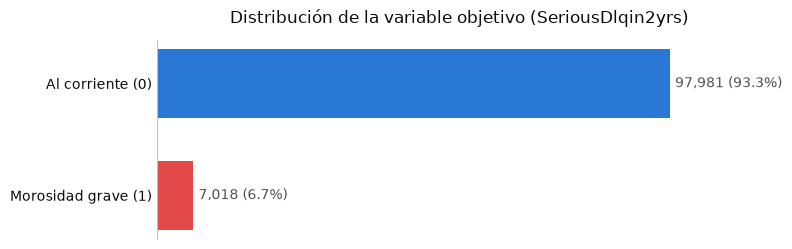

In [36]:
# Distribución de la variable objetivo (sobre el conjunto completo)
conteo = y.value_counts().sort_index()
prop = y.value_counts(normalize=True).sort_index()
etiquetas = ["Al corriente (0)", "Morosidad grave (1)"]
colores = ["#2a78d6", "#e34948"]  # azul (mayoría) / rojo (minoría)

fig, ax = plt.subplots(figsize=(8, 2.6))
barras = ax.barh(etiquetas, conteo.values, color=colores, height=0.62)

# Etiquetas directas: recuento y porcentaje al final de cada barra
for barra, n, p in zip(barras, conteo.values, prop.values):
    ax.text(n + max(conteo.values) * 0.01, barra.get_y() + barra.get_height() / 2,
            f"{n:,} ({p:.1%})", va="center", ha="left", fontsize=10, color="#52514e")

# Cromo recesivo: sin rejilla ni eje X (los valores están en las etiquetas)
ax.set_xlim(0, max(conteo.values) * 1.18)
ax.set_title("Distribución de la variable objetivo (SeriousDlqin2yrs)", fontsize=12, color="#0b0b0b", pad=12)
for s in ["top", "right", "bottom"]:
    ax.spines[s].set_visible(False)
ax.spines["left"].set_color("#c3c2b7")
ax.tick_params(axis="y", length=0, labelsize=10, colors="#0b0b0b")
ax.set_xticks([])
ax.invert_yaxis()  # clase 0 arriba
plt.tight_layout()
plt.show()

La clase `LimpiadorCreditScoring` consolida, en forma segura ante *leakage*, exactamente las mismas decisiones de limpieza que tomamos en el EDA:

- **`fit(X_train)`** aprende: medianas por tramo de edad de `MonthlyIncome` y `NumberOfDependents`, el percentil 95 de `DebtRatio` y el máximo legítimo de cada contador de morosidad.
- **`transform(X)`** aplica esos parámetros a cualquier conjunto: imputa con las medianas aprendidas (+ flags `_missing`), winsoriza `Revolving` a 10 y `DebtRatio` al p95 de train, y sustituye los centinelas 96/98 por el máximo legítimo de train (+ flag `PastDue_centinela`).

In [37]:
class LimpiadorCreditScoring:
    """Limpieza del dataset con patrón fit/transform para evitar data leakage.

    Aprende todos los parámetros que dependen de los datos usando SOLO el conjunto de
    entrenamiento (`fit`) y los aplica a cualquier conjunto (`transform`).
    """

    def __init__(self, cortes, centinelas=(96, 98)):
        self.cortes = cortes
        self.centinelas = list(centinelas)
        self.cols_morosidad = [
            "NumberOfTime30-59DaysPastDueNotWorse",
            "NumberOfTimes90DaysLate",
            "NumberOfTime60-89DaysPastDueNotWorse",
        ]

    def fit(self, X):
        tramo = pd.cut(X["age"], self.cortes)
        # Medianas por tramo de edad (y mediana global como respaldo) para imputar
        self.medianas_, self.mediana_global_ = {}, {}
        for col in ["MonthlyIncome", "NumberOfDependents"]:
            self.medianas_[col] = X.groupby(tramo, observed=True)[col].median()
            self.mediana_global_[col] = X[col].median()
        # Topes de winsorización
        self.tope_revolving_ = 10  # constante (no se aprende de los datos)
        self.tope_debtratio_ = X["DebtRatio"].quantile(0.95)
        # Máximo legítimo de cada contador (excluyendo los centinelas)
        self.max_legit_ = {
            c: int(X.loc[~X[c].isin(self.centinelas), c].max()) for c in self.cols_morosidad
        }
        return self

    def transform(self, X):
        X = X.copy()
        tramo = pd.cut(X["age"], self.cortes)

        # Imputación por mediana de tramo aprendida + flag de valor ausente
        for col in ["MonthlyIncome", "NumberOfDependents"]:
            X[f"{col}_missing"] = X[col].isna().astype(int)
            relleno = tramo.map(self.medianas_[col].to_dict()).astype(float)
            X[col] = X[col].fillna(relleno).fillna(self.mediana_global_[col])

        # Winsorización con los topes aprendidos en train
        X["RevolvingUtilizationOfUnsecuredLines"] = X["RevolvingUtilizationOfUnsecuredLines"].clip(upper=self.tope_revolving_)
        X["DebtRatio"] = X["DebtRatio"].clip(upper=self.tope_debtratio_)

        # Valores centinela: flag compartido + sustitución por el máximo legítimo de train
        X["PastDue_centinela"] = X[self.cols_morosidad].isin(self.centinelas).any(axis=1).astype(int)
        for c in self.cols_morosidad:
            X.loc[X[c].isin(self.centinelas), c] = self.max_legit_[c]

        return X

In [38]:
# Aprendemos los parámetros SOLO con train y transformamos ambos conjuntos
limpiador = LimpiadorCreditScoring(cortes).fit(X_train)
X_train_limpio = limpiador.transform(X_train)
X_test_limpio = limpiador.transform(X_test)

# Parámetros aprendidos en train
print("Parámetros aprendidos (solo train):")
print(f"  Tope DebtRatio (p95): {limpiador.tope_debtratio_:.2f}")
print(f"  Máx. legítimo contadores: {limpiador.max_legit_}")

# Verificación de ausencia de nulos y de centinelas en ambos conjuntos
for nombre, Xc in [("train", X_train_limpio), ("test", X_test_limpio)]:
    nulos = int(Xc.isna().sum().sum())
    quedan_cent = bool(Xc[limpiador.cols_morosidad].isin(limpiador.centinelas).any().any())
    print(f"\n{nombre}: {Xc.shape[0]} filas x {Xc.shape[1]} columnas | nulos: {nulos} | quedan centinelas: {quedan_cent}")
    assert nulos == 0 and not quedan_cent

print("\nEl tope de DebtRatio y demás parámetros provienen solo de train: no hay data leakage.")

Parámetros aprendidos (solo train):
  Tope DebtRatio (p95): 2466.00
  Máx. legítimo contadores: {'NumberOfTime30-59DaysPastDueNotWorse': 12, 'NumberOfTimes90DaysLate': 15, 'NumberOfTime60-89DaysPastDueNotWorse': 8}

train: 83999 filas x 13 columnas | nulos: 0 | quedan centinelas: False

test: 21000 filas x 13 columnas | nulos: 0 | quedan centinelas: False

El tope de DebtRatio y demás parámetros provienen solo de train: no hay data leakage.
